In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns when printing DataFrames
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload the dataset from your computer

from google.colab import files

uploaded = files.upload()

Saving final_dav_dataset (1).csv to final_dav_dataset (1).csv


In [4]:
# Read the uploaded CSV file

df = pd.read_csv("final_dav_dataset (1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# -------------------------------
# DATASET PROFILE
# -------------------------------

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

print("\nDataset information:")
df.info()

Number of rows: 5000
Number of columns: 4

Column names:
['Event Type', 'Attendees', 'Expenses', 'Success']

Data types:
Event Type    object
Attendees      int64
Expenses       int64
Success        int64
dtype: object

First 5 records:


,Event Type,Attendees,Expenses,Success
0,Sports,853,35012,0
1,Cultural,670,159726,1
2,Cultural,1113,176284,1
3,Sports,1074,218188,1
4,Seminars,1013,192829,1



Last 5 records:


,Event Type,Attendees,Expenses,Success
4995,Cultural,1200,142754,1
4996,Seminars,776,19817,1
4997,Seminars,626,152360,1
4998,Seminars,109,11327,1
4999,Cultural,136,30907,1



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Event Type  5000 non-null   object
 1   Attendees   5000 non-null   int64 
 2   Expenses    5000 non-null   int64 
 3   Success     5000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 156.4+ KB


In [6]:
# -------------------------------
# SUMMARY STATISTICS
# -------------------------------

print("Summary statistics:")
display(df.describe())

print("\nSummary including categorical columns:")
display(df.describe(include='all'))

Summary statistics:


,Attendees,Expenses,Success
count,5000.000000,5000.000000,5000.00000
mean,795.395000,89527.583400,0.92000
std,405.928268,66269.743684,0.27132
min,100.000000,2019.000000,0.00000
25%,438.000000,33377.000000,1.00000
50%,801.000000,74418.500000,1.00000
75%,1139.250000,135492.750000,1.00000
max,1500.000000,249764.000000,1.00000



Summary including categorical columns:


,Event Type,Attendees,Expenses,Success
count,5000,5000.000000,5000.000000,5000.00000
unique,3,NaN,NaN,NaN
top,Sports,NaN,NaN,NaN
freq,1681,NaN,NaN,NaN
mean,NaN,795.395000,89527.583400,0.92000
std,NaN,405.928268,66269.743684,0.27132
min,NaN,100.000000,2019.000000,0.00000
25%,NaN,438.000000,33377.000000,1.00000
50%,NaN,801.000000,74418.500000,1.00000
75%,NaN,1139.250000,135492.750000,1.00000


In [7]:
# -------------------------------
# DUPLICATE DETECTION
# -------------------------------

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# -------------------------------
# REMOVE DUPLICATES
# -------------------------------

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5000, 4)


In [9]:
# -------------------------------
# MISSING VALUE CHECK
# -------------------------------

print("Missing values in each column:")

missing_values = df.isnull().sum()

display(missing_values)

Missing values in each column:


,0
Event Type,0
Attendees,0
Expenses,0
Success,0


In [10]:
# -------------------------------
# MISSING VALUE COUNT & PERCENTAGE
# -------------------------------

missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

display(missing_summary)

,Missing Count,Missing Percentage
Event Type,0,0.0
Attendees,0,0.0
Expenses,0,0.0
Success,0,0.0


In [11]:
# -------------------------------
# IDENTIFY COLUMN TYPES
# -------------------------------

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Attendees', 'Expenses', 'Success']

Categorical columns:
['Event Type']


In [12]:
# -------------------------------
# CATEGORICAL VARIABLE ANALYSIS
# -------------------------------

for column in categorical_columns:
    print("\nColumn:", column)
    print("Unique values:")
    print(df[column].unique())

    print("\nValue counts:")
    print(df[column].value_counts())


Column: Event Type
Unique values:
['Sports' 'Cultural' 'Seminars']

Value counts:
Event Type
Sports      1681
Cultural    1672
Seminars    1647
Name: count, dtype: int64


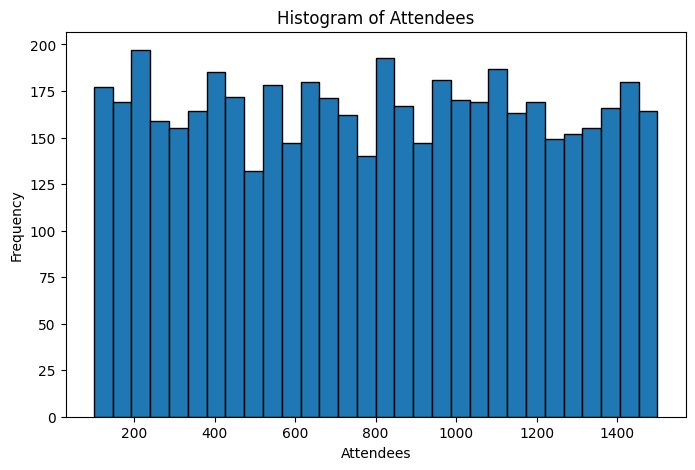

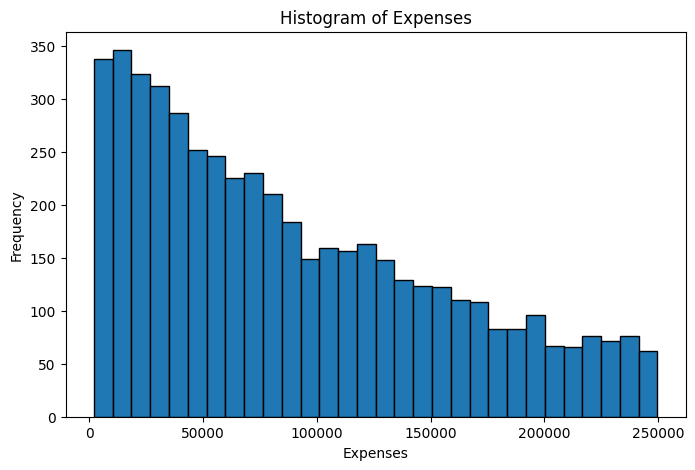

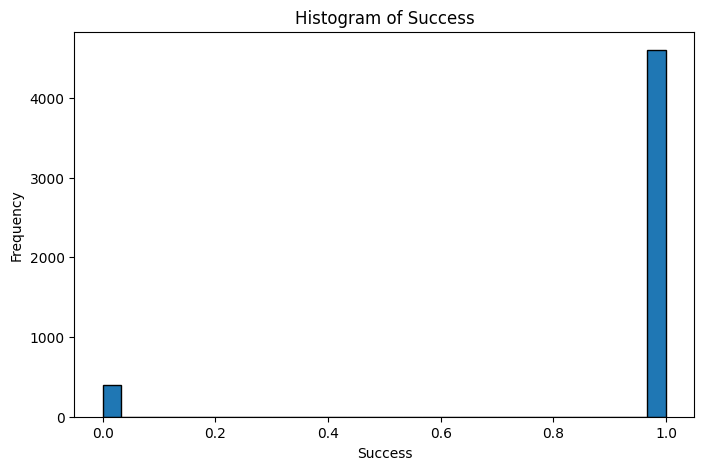

In [13]:
# -------------------------------
# HISTOGRAMS
# -------------------------------

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(df[column], bins=30, edgecolor='black')

    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

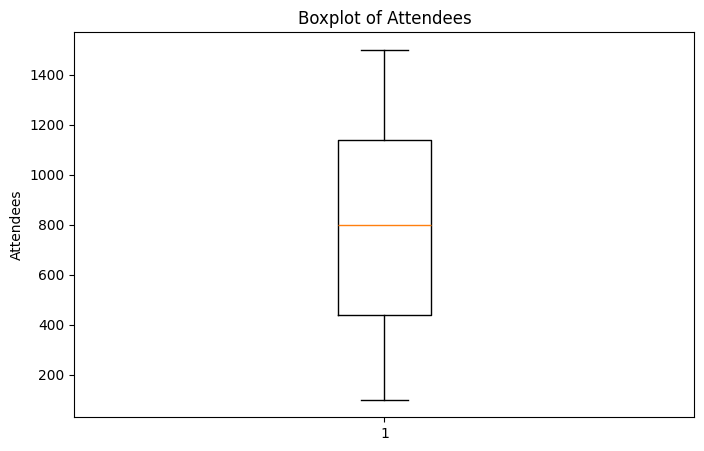

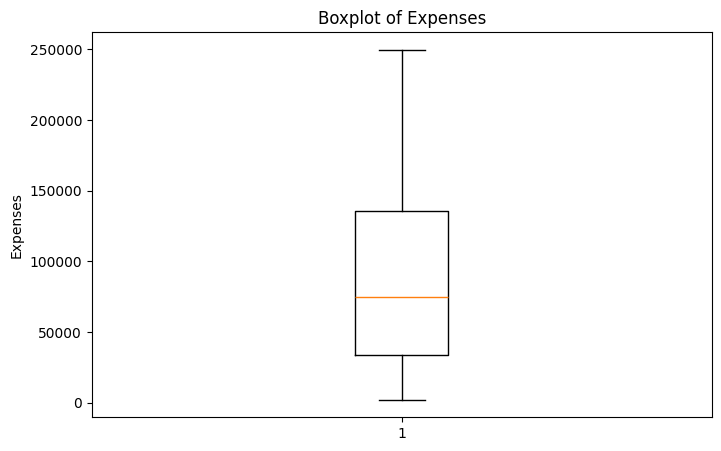

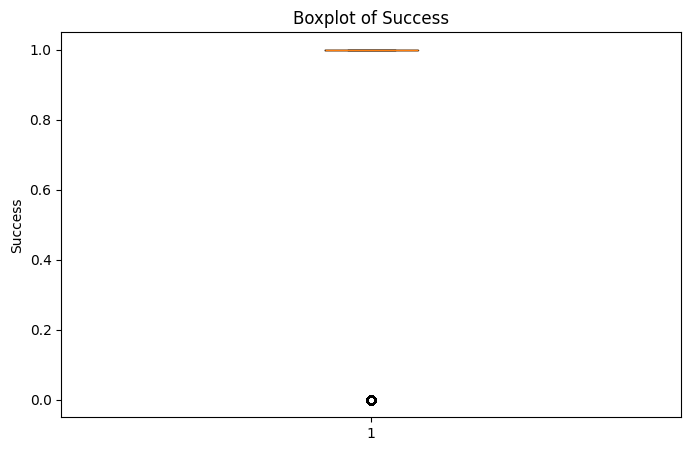

In [14]:
# -------------------------------
# BOXPLOTS
# -------------------------------

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    plt.boxplot(df[column].dropna())

    plt.title("Boxplot of " + column)
    plt.ylabel(column)

    plt.show()

In [15]:
# -------------------------------
# IQR OUTLIER DETECTION
# -------------------------------

# We check the main continuous numeric columns
# Success is a binary variable, so we don't treat it as a continuous
# outlier variable.

outlier_columns = ['Attendees', 'Expenses']

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Column: Attendees
Q1: 438.0
Q3: 1139.25
IQR: 701.25
Lower Bound: -613.875
Upper Bound: 2191.125
Number of outliers: 0

Column: Expenses
Q1: 33377.0
Q3: 135492.75
IQR: 102115.75
Lower Bound: -119796.625
Upper Bound: 288666.375
Number of outliers: 0


In [16]:
# -------------------------------
# REMOVE OUTLIERS USING IQR
# -------------------------------

df_clean = df.copy()

for column in outlier_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original number of rows:", len(df))
print("Rows after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original number of rows: 5000
Rows after outlier removal: 5000
Rows removed: 0


In [17]:
# -------------------------------
# MISSING VALUES AFTER OUTLIER REMOVAL
# -------------------------------

print("Missing values before imputation:")

display(df_clean.isnull().sum())

Missing values before imputation:


,0
Event Type,0
Attendees,0
Expenses,0
Success,0


In [18]:
# -------------------------------
# MEAN VS MEDIAN
# -------------------------------

for column in numerical_columns:

    mean_value = df_clean[column].mean()
    median_value = df_clean[column].median()

    print("\nColumn:", column)
    print("Mean:", mean_value)
    print("Median:", median_value)
    print("Difference:", abs(mean_value - median_value))


Column: Attendees
Mean: 795.395
Median: 801.0
Difference: 5.605000000000018

Column: Expenses
Mean: 89527.5834
Median: 74418.5
Difference: 15109.083400000003

Column: Success
Mean: 0.92
Median: 1.0
Difference: 0.07999999999999996


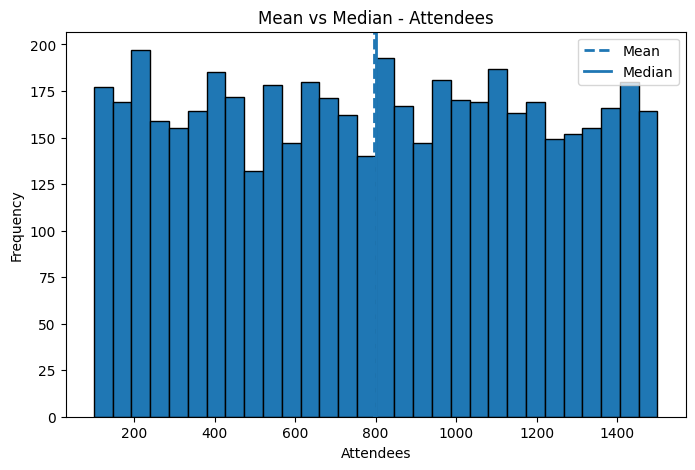

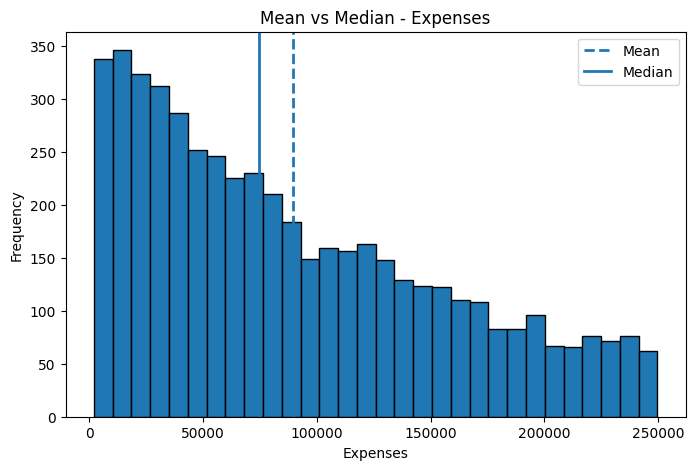

In [19]:
# -------------------------------
# MEAN VS MEDIAN VISUALIZATION
# -------------------------------

for column in ['Attendees', 'Expenses']:

    mean_value = df_clean[column].mean()
    median_value = df_clean[column].median()

    plt.figure(figsize=(8, 5))

    plt.hist(df_clean[column], bins=30, edgecolor='black')

    plt.axvline(mean_value, linestyle='--', linewidth=2, label='Mean')
    plt.axvline(median_value, linestyle='-', linewidth=2, label='Median')

    plt.title("Mean vs Median - " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

In [20]:
# -------------------------------
# MEDIAN IMPUTATION
# -------------------------------

for column in numerical_columns:

    median_value = df_clean[column].median()

    df_clean[column] = df_clean[column].fillna(median_value)

print("Median imputation completed!")

Median imputation completed!


In [21]:
# -------------------------------
# CATEGORICAL IMPUTATION
# -------------------------------

for column in categorical_columns:

    mode_value = df_clean[column].mode()[0]

    df_clean[column] = df_clean[column].fillna(mode_value)

    print(column, "missing values replaced with:", mode_value)

Event Type missing values replaced with: Sports


In [22]:
# -------------------------------
# FINAL MISSING VALUE CHECK
# -------------------------------

print("Missing values after imputation:")

display(df_clean.isnull().sum())

Missing values after imputation:


,0
Event Type,0
Attendees,0
Expenses,0
Success,0


In [23]:
# -------------------------------
# FINAL DUPLICATE CHECK
# -------------------------------

print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Duplicate rows after cleaning: 0


In [24]:
# -------------------------------
# FINAL DATASET PROFILE
# -------------------------------

print("FINAL DATASET PROFILE")
print("----------------------")

print("Number of rows:", df_clean.shape[0])
print("Number of columns:", df_clean.shape[1])

print("\nColumn names:")
print(df_clean.columns.tolist())

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values:")
display(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nFinal summary statistics:")
display(df_clean.describe())

FINAL DATASET PROFILE
----------------------
Number of rows: 5000
Number of columns: 4

Column names:
['Event Type', 'Attendees', 'Expenses', 'Success']

Data types:
Event Type    object
Attendees      int64
Expenses       int64
Success        int64
dtype: object

Missing values:


,0
Event Type,0
Attendees,0
Expenses,0
Success,0



Duplicate rows:
0

Final summary statistics:


,Attendees,Expenses,Success
count,5000.000000,5000.000000,5000.00000
mean,795.395000,89527.583400,0.92000
std,405.928268,66269.743684,0.27132
min,100.000000,2019.000000,0.00000
25%,438.000000,33377.000000,1.00000
50%,801.000000,74418.500000,1.00000
75%,1139.250000,135492.750000,1.00000
max,1500.000000,249764.000000,1.00000


In [25]:
# -------------------------------
# BEFORE VS AFTER CLEANING
# -------------------------------

comparison = pd.DataFrame({
    'Before Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],

    'After Cleaning': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
}, index=[
    'Number of Rows',
    'Number of Columns',
    'Total Missing Values',
    'Duplicate Rows'
])

display(comparison)

,Before Cleaning,After Cleaning
Number of Rows,5000,5000
Number of Columns,4,4
Total Missing Values,0,0
Duplicate Rows,0,0


In [26]:
# -------------------------------
# SAVE CLEANED DATASET
# -------------------------------

df_clean.to_csv("final_dav_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [28]:
# Download the cleaned CSV file to your computer

from google.colab import files

files.download("final_dav_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>